# PerceptionMetrics CityScapes image segmentation tutorial
Cityscapes is a popular dataset for benchmarking image segmentation algorithms. In this tutorial, we will show how to use PerceptionMetrics to evaluate the performance of an image segmentation model on the Cityscapes dataset.

## Download required data

To run this tutorial, you will need to download the Cityscapes dataset and the pretrained SegFormer model. You can download the Cityscapes dataset from the [Cityscapes website](https://www.cityscapes-dataset.com/downloads/). Save the ground truth and image data in a local directory, e.g., `local/data/cityscapes`. 

### Config File Setup

In [10]:
import json
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation

model_name = "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"

processor = AutoImageProcessor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)

cfg = processor.to_dict()

pm_cfg = {
    "resize": {
        "height": cfg["size"]["height"],
        "width": cfg["size"]["width"],
    },
    "normalization": {
        "mean": list(cfg["image_mean"]),
        "std": list(cfg["image_std"]),
    },

}

model_cfg_path = "local/data/segformer_cityscapes_cfg.json"

with open(model_cfg_path, "w") as f:
    json.dump(pm_cfg, f, indent=2)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

## Setup Model

In [ ]:
!pip install transformers

from transformers import SegformerForSemanticSegmentation
from perceptionmetrics.models.torch_segmentation import TorchImageSegmentationModel



model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
)


pm_model = TorchImageSegmentationModel(
    model=model,
    model_cfg="local/data/segformer_cityscapes_cfg.json",
    ontology_fname="local/data/cityscapes_ontology.json",
)

## Setup dataset

In [12]:
from perceptionmetrics.datasets.cityscapes import (
    CityscapesImageSegmentationDataset,
    build_dataset_ontology,
    build_train_id_ontology_translation,
)

dataset = CityscapesImageSegmentationDataset(
    # train_dataset_root="local/data/cityscapes",
    val_dataset_root="local/data/cityscapes",
    use_train_id=False,
)

train_id_ontology = build_dataset_ontology(
    use_train_id=True,
    ontology_fname="local/data/cityscapes_trainid_ontology.json",
)

ontology_translation = build_train_id_ontology_translation()

dataset.export(
    outdir="local/data/cityscapes_trainids",
    new_ontology=train_id_ontology,
    ontology_translation=ontology_translation,
)
dataset.make_fname_global()


Samples retrieved: 500


Exporting sample: munster_000173_000019: : 500it [00:15, 33.14it/s]  


## Inference

Image filename: local/data/cityscapes_trainids/val/image-frankfurt_000000_000294.png


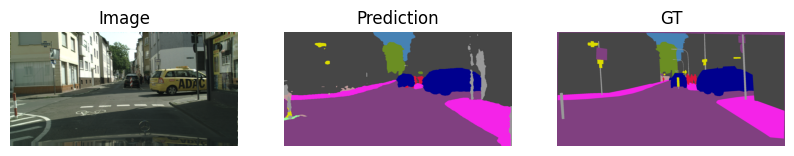

In [13]:
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image

from perceptionmetrics.utils import conversion as uc

image_fname = dataset.dataset["image"].iloc[0]
print (f"Image filename: {image_fname}")
image = Image.open(image_fname)

label_fname = dataset.dataset["label"].iloc[0]
label = Image.open(label_fname)
label = uc.label_to_rgb(label, dataset.ontology)

pred = pm_model.predict(image)
pred = uc.label_to_rgb(pred, pm_model.ontology)
pred = pred.resize(label.size)

plt.figure(figsize=(10, 10))
plt.subplot(131), plt.title("Image"), plt.imshow(np.array(image)), plt.axis("off")
plt.subplot(132), plt.title("Prediction"), plt.imshow(np.array(pred)), plt.axis("off")
plt.subplot(133), plt.title("GT"), plt.imshow(np.array(label)), plt.axis("off")
plt.show()

## Evaluation

In [9]:
results = pm_model.eval(dataset, split="val")
display(results)

100%|██████████| 500/500 [00:29<00:00, 17.23it/s]


,road,sidewalk,building,wall,fence,pole,traffic light,traffic sign,vegetation,terrain,...,person,rider,car,truck,bus,train,motorcycle,bicycle,macro,micro
tp,5.337566e+07,5.089345e+06,2.374316e+07,4.406170e+05,5.924240e+05,7.056870e+05,8.890600e+04,4.204710e+05,1.886203e+07,6.356410e+05,...,1.038419e+06,7.473200e+04,6.997442e+06,2.295730e+05,3.028140e+05,1.030790e+05,3.528600e+04,5.783310e+05,NaN,NaN
fp,7.103570e+05,1.540475e+06,4.381386e+06,2.829110e+05,9.117680e+05,8.267700e+05,3.822800e+04,2.027030e+05,2.537591e+06,2.827620e+05,...,5.492930e+05,5.531500e+04,7.868940e+05,9.574000e+04,7.396600e+04,9.417800e+04,1.979800e+04,2.957320e+05,NaN,NaN
fn,6.078513e+06,1.123064e+06,1.437465e+06,4.016160e+05,3.503510e+05,9.905150e+05,1.372700e+05,3.431540e+05,1.034882e+06,3.201400e+05,...,4.525730e+05,1.725260e+05,4.847260e+05,1.157450e+05,1.428670e+05,2.586400e+04,5.603100e+04,2.362240e+05,NaN,NaN
tn,7.090747e+07,1.233191e+08,1.015100e+08,1.299469e+08,1.292175e+08,1.285490e+08,1.308076e+08,1.301057e+08,1.086375e+08,1.298335e+08,...,1.290317e+08,1.307694e+08,1.228029e+08,1.306309e+08,1.305524e+08,1.308489e+08,1.309609e+08,1.299617e+08,NaN,NaN
precision,9.868662e-01,7.676445e-01,8.442149e-01,6.089840e-01,3.938487e-01,4.604938e-01,6.993094e-01,6.747249e-01,8.814189e-01,6.921156e-01,...,6.540349e-01,5.746538e-01,8.989132e-01,7.056988e-01,8.036892e-01,5.225619e-01,6.405853e-01,6.616583e-01,0.703713,0.892451
recall,8.977614e-01,8.192225e-01,9.429139e-01,5.231533e-01,6.283832e-01,4.160395e-01,3.930833e-01,5.506250e-01,9.479878e-01,6.650488e-01,...,6.964618e-01,3.022430e-01,9.352158e-01,6.648162e-01,6.794411e-01,7.994152e-01,3.864122e-01,7.099963e-01,0.679375,0.892451
accuracy,9.482050e-01,9.796788e-01,9.556057e-01,9.947775e-01,9.903708e-01,9.861352e-01,9.986611e-01,9.958354e-01,9.727442e-01,9.954002e-01,...,9.923564e-01,9.982617e-01,9.902983e-01,9.983865e-01,9.983457e-01,9.990842e-01,9.994215e-01,9.959415e-01,0.988679,0.988679
f1_score,9.402073e-01,7.925953e-01,8.908389e-01,5.628151e-01,4.842109e-01,4.371394e-01,5.032747e-01,6.063907e-01,9.134922e-01,6.783123e-01,...,6.745819e-01,3.961358e-01,9.167052e-01,6.846477e-01,7.363608e-01,6.319988e-01,4.820459e-01,6.849755e-01,0.681082,0.892451
iou,8.871616e-01,6.564454e-01,8.031646e-01,3.916094e-01,3.194447e-01,2.797046e-01,3.362506e-01,4.351224e-01,8.407599e-01,5.132167e-01,...,5.089578e-01,2.469883e-01,8.462196e-01,5.205052e-01,5.827302e-01,4.619870e-01,3.175629e-01,5.208842e-01,0.543534,0.805790
dice_score,9.402073e-01,7.925953e-01,8.908389e-01,5.628151e-01,4.842109e-01,4.371394e-01,5.032747e-01,6.063907e-01,9.134922e-01,6.783123e-01,...,6.745819e-01,3.961358e-01,9.167052e-01,6.846477e-01,7.363608e-01,6.319988e-01,4.820459e-01,6.849755e-01,0.681082,0.892451
